In [2]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [3]:
Portfolio_tickers = ['NKE', 'SPOT', 'T', 'JPM', 'DIS', 'TM', 'KO']
Index_tickers = ['DIA', 'SPY', 'IWM']
tickers = Portfolio_tickers + Index_tickers

data = yf.download(tickers=tickers,auto_adjust=False, period= '10y', interval = '1d')

data = data['Adj Close']

returns = data.pct_change().dropna()

portfolio_weight = 1 / len(Portfolio_tickers)
results1 = []

for ticker in Portfolio_tickers:
    prices = data[ticker]
    asset_returns = returns[ticker]

    rolling_vol = asset_returns.rolling(91).std()                               #Code cited from:
    volatility = (rolling_vol.mean() * np.sqrt(252))                            #https://stackoverflow.com/questions/52941128/how-to-calculate-volatility-with-pandas

    beta_DIA = asset_returns.cov(returns['DIA']) / returns['DIA'].var()          #Code cited from:
    beta_SPY = asset_returns.cov(returns['SPY']) / returns['SPY'].var()          #https://stackoverflow.com/questions/59110902/is-there-anyway-to-calculate-market-beta-from-yahoo-finance-datasreader-on-pytho
    beta_IWM = asset_returns.cov(returns['IWM']) / returns['IWM'].var()
  
    weekly_high = prices.rolling(364).max()
    weekly_low = prices.rolling(364).min()
    avg_drawdown = ((weekly_low - weekly_high) / weekly_high).mean()
    max_drawdown = ((weekly_low - weekly_high) / weekly_high).min()
    
    total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    annualized_return = (1 + total_return) ** (1 / 10) - 1
    
    results1.append([
        ticker,
        portfolio_weight,
        volatility,
        beta_SPY,
        beta_IWM,
        beta_DIA,
        avg_drawdown,
        max_drawdown,
        total_return,
        annualized_return
        
    ])


columns = ['Ticker', 'Portfolio Weight', 'Annualized Volatility', 'Beta (SPY)', 'Beta (IWM)', 'Beta (DIA)',
           'Avg Weekly Drawdown', 'Max Weekly Drawdown', 'Total Return', 'Annualized Return']
df1 = pd.DataFrame(results1, columns=columns)
df1

[*********************100%***********************]  10 of 10 completed


,Ticker,Portfolio Weight,Annualized Volatility,Beta (SPY),Beta (IWM),Beta (DIA),Avg Weekly Drawdown,Max Weekly Drawdown,Total Return,Annualized Return
0,NKE,0.142857,0.314263,1.044786,0.740441,1.052745,-0.389655,-0.642635,0.805393,0.060858
1,SPOT,0.142857,0.458696,1.129150,0.805874,0.891090,-0.636314,-0.783131,NaN,NaN
2,T,0.142857,0.240483,0.614864,0.442754,0.703118,-0.293939,-0.519628,1.161268,0.080117
3,JPM,0.142857,0.268254,1.075844,0.832334,1.208665,-0.395113,-0.544850,4.438541,0.184536
4,DIS,0.142857,0.296934,1.014793,0.761099,1.052730,-0.365129,-0.575256,0.143639,0.013512
5,TM,0.142857,0.228427,0.684341,0.499827,0.687324,-0.305733,-0.483796,0.516873,0.042545
6,KO,0.142857,0.180275,0.588961,0.358816,0.655000,-0.241230,-0.372624,1.319687,0.087785


In [4]:
risk_free_rate = 0.043 / 252                        #risk free rate found from https://ycharts.com/indicators/10_year_treasury_rate
                         
results2 = []

portfolio_returns = returns[Portfolio_tickers].mean(axis=1)

portfolio_vol = portfolio_returns.std() * np.sqrt(252)

for etf in Index_tickers:
    etf_returns = returns[etf]
    
    correlation = portfolio_returns.corr(etf_returns)
    
    covariance = portfolio_returns.cov(etf_returns)  
    
    tracking_error = np.std(portfolio_returns - etf_returns) * np.sqrt(252)       #code cited from https://portfolio-geek.com/posts/articles/tutorials/tracking-error
    
    sharpe_ratio = (portfolio_returns.mean() - risk_free_rate) / portfolio_vol

    etf_vol = etf_returns.std() * np.sqrt(252)
    vol_spread = portfolio_vol - etf_vol
    
    results2.append([
        etf,
        correlation,
        covariance,
        tracking_error,
        sharpe_ratio,
        vol_spread

   ])


columns = ['ETF Ticker', 'Correlation', 'Covariance', 'Tracking Error', 'Sharpe Ratio', 'Volatility Spread']
df2 = pd.DataFrame(results2, columns=columns)
df2

,ETF Ticker,Correlation,Covariance,Tracking Error,Sharpe Ratio,Volatility Spread
0,DIA,0.857943,0.000129,0.104027,0.001908,0.007787
1,SPY,0.854924,0.000130,0.105616,0.001908,0.005432
2,IWM,0.794845,0.000156,0.150942,0.001908,-0.050209


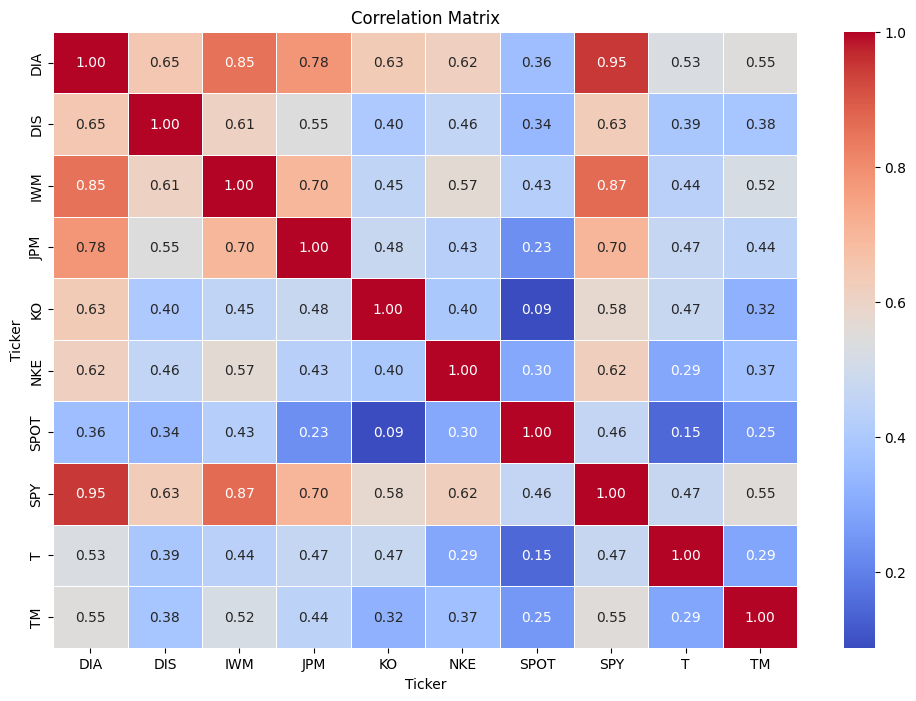

In [5]:
correlation_matrix = returns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()